# Clasificación y estimación facial mediante Python para la seguridad en entornos   

## Descripción del dataset FGNET

In [186]:
#Librerias

import pandas as pd
import os
import re
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from pathlib import Path 
from deepface import DeepFace
from tqdm import tqdm
import seaborn as sns 

import warnings
warnings.filterwarnings('ignore')


In [187]:
# Cargar el dataset
dataset = Path("/Users/camilazuniga/Desktop/DATA SCIENCE/AED/FGNET/images")
ruta_csv = "/Users/camilazuniga/Documents/GitHub/EDA-FGNET/FGNET_dataset.csv"


if dataset.exists():
    print("El dataset se ha cargado correctamente.")
else:
    print("El dataset no se encuentra en la ruta especificada.")

El dataset se ha cargado correctamente.


Se encontraron 1002 imágenes en el dataset.


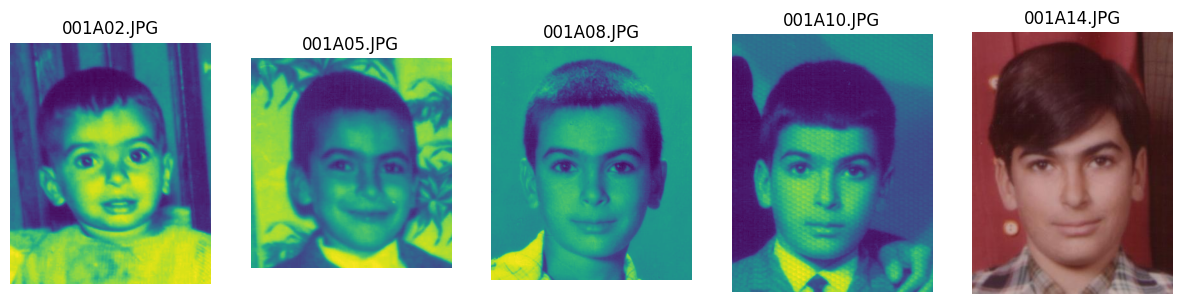

Las cinco primeras imágenes del dataset:
  - 001A02.JPG
  - 001A05.JPG
  - 001A08.JPG
  - 001A10.JPG
  - 001A14.JPG


In [188]:
# Listar imágenes en el dataset
extensiones = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'}
image = [f for f in dataset.iterdir() if f.suffix.lower() in extensiones]
image = sorted(image, key=lambda x: x.name)
print(f"Se encontraron {len(image)} imágenes en el dataset.")

# Mostrar las primeras 5 imágenes
num_images_to_show = 5
plt.figure(figsize=(15, 10))
for i, image_file in enumerate(image[:num_images_to_show]):
    img = Image.open(image_file)
    plt.subplot(1, num_images_to_show, i + 1)
    plt.imshow(img)
    plt.title(image_file.name)
    plt.axis('off')
plt.show()

print("Las cinco primeras imágenes del dataset:")
for img in image[:5]:
    print(f"  - {img.name}")

# Función para extraer edad del nombre del archivo
# FGNET usa formato: "001a01.jpg" → ID=001, Edad=01
def extraer_edad(nombre_archivo):
    stem = Path(nombre_archivo).stem
    # Busca el patrón: letras seguidas de dígitos (la edad)
    match = re.search(r'[a-zA-Z](\d+)', stem)
    if match:
        return int(match.group(1))
    else:
        return None


In [189]:
# Crear DataFrame con datos estructurados 
data = []

for img in image:
    stats = img.stat()
    edad = extraer_edad(img.name)
    data.append({
        'imagenes': img.name,
        'Tamaño_KB': round(stats.st_size / 1024, 2),
        'Edad': edad,
        'Sexo': None,
        'R': None,
        'G': None,
        'B': None
    })

df = pd.DataFrame(data)
df = df.sort_values('imagenes').reset_index(drop=True)

# Guardar CSV inicial
df.to_csv(ruta_csv, index=False)

print(f"CSV creado con {len(df)} imágenes")
print(f"   Edad detectada: {df['Edad'].notna().sum()}")
print(f"   Edad no detectada: {df['Edad'].isna().sum()}")



CSV creado con 1002 imágenes
   Edad detectada: 1002
   Edad no detectada: 0


In [190]:
# Cargar el dataset desde el CSV
df = pd.read_csv(ruta_csv)
print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")

Dataset cargado: 1002 filas, 7 columnas


In [191]:
# Implementar DeepFace para analizar género
print("Analizando género en cada imagen...")
predicciones = []

for img_name in tqdm(df['imagenes'], desc="Procesando género"):
    img_path = dataset / img_name
    try:
        analisis = DeepFace.analyze(
            str(img_path), 
            actions=['gender'], 
            detector_backend='opencv', 
            enforce_detection=False,
            silent=True
        )
        genero = analisis[0]['dominant_gender']  
        predicciones.append(genero)
    except Exception:
        predicciones.append('No_detectado')

df['Sexo'] = predicciones

# Guardar 
df.to_csv(ruta_csv, index=False)

print(f"\nDistribución estimada de género:")
print(df['Sexo'].value_counts())

Analizando género en cada imagen...


Procesando género: 100%|██████████| 1002/1002 [01:50<00:00,  9.08it/s]


Distribución estimada de género:
Sexo
Man      720
Woman    282
Name: count, dtype: int64


In [192]:
# Implementar la variable RGB para cada imagen
print("\nAnalizando color RGB en cada imagen...")
rgb_values = [] 
for img_name in tqdm(df['imagenes'], desc="Procesando RGB"):
    img_path = dataset / img_name
    try:
        img = cv2.imread(str(img_path))
        if img is not None:
            bgr = cv2.mean(img)[:3]  
            rgb = tuple(reversed(bgr))
            rgb_values.append(rgb)
        else:
            rgb_values.append((0, 0, 0))  
    except Exception:
        rgb_values.append((0, 0, 0))

df['RGB'] = rgb_values
df[['R', 'G', 'B']] = pd.DataFrame(df['RGB'].tolist(), index=df.index)

# Guardar 
df.to_csv(ruta_csv, index=False)

print("Análisis RGB completado")


Analizando color RGB en cada imagen...


Procesando RGB: 100%|██████████| 1002/1002 [00:00<00:00, 1494.57it/s]

Análisis RGB completado


In [193]:
# Mostrar el dataset 
print("=" * 60)
print("DATASET FGNET") #con datos estructurados"
print("=" * 60)

print(f"\nDimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"\nColumnas: {list(df.columns)}")

print("\n Primeras 10 filas del dataset:")
display(df.head(10))

print("\n Información del dataset:")
df.info()

print("\n Estadísticas descriptivas:")
display(df.describe())


DATASET FGNET

Dimensiones: 1002 filas × 8 columnas

Columnas: ['imagenes', 'Tamaño_KB', 'Edad', 'Sexo', 'R', 'G', 'B', 'RGB']

 Primeras 10 filas del dataset:


,imagenes,Tamaño_KB,Edad,Sexo,R,G,B,RGB
0,001A02.JPG,9.55,2,Woman,102.936847,102.936847,102.936847,"(102.93684728745984, 102.93684728745984, 102.9..."
1,001A05.JPG,12.55,5,Man,133.466402,133.466402,133.466402,"(133.46640236073256, 133.46640236073256, 133.4..."
2,001A08.JPG,12.54,8,Man,138.786665,138.786665,138.786665,"(138.78666468886746, 138.78666468886746, 138.7..."
3,001A10.JPG,14.12,10,Man,111.491709,111.491709,111.491709,"(111.49170883317224, 111.49170883317224, 111.4..."
4,001A14.JPG,10.57,14,Man,114.376567,64.713975,63.699782,"(114.3765671746721, 64.71397548763055, 63.6997..."
5,001A16.JPG,58.06,16,Man,126.296435,126.296435,126.296435,"(126.29643549263342, 126.29643549263342, 126.2..."
6,001A18.JPG,16.39,18,Man,150.180489,76.964194,61.682092,"(150.18048877097957, 76.96419425560529, 61.682..."
7,001A19.JPG,18.52,19,Man,156.591782,76.827312,58.073008,"(156.59178216974675, 76.82731220054757, 58.073..."
8,001A22.JPG,34.81,22,Man,159.241437,128.307665,113.630621,"(159.24143701982277, 128.3076646260037, 113.63..."
9,001A28.JPG,14.51,28,Man,94.887594,87.523791,87.852513,"(94.88759449562959, 87.523791243405, 87.852512..."



 Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   imagenes   1002 non-null   object 
 1   Tamaño_KB  1002 non-null   float64
 2   Edad       1002 non-null   int64  
 3   Sexo       1002 non-null   object 
 4   R          1002 non-null   float64
 5   G          1002 non-null   float64
 6   B          1002 non-null   float64
 7   RGB        1002 non-null   object 
dtypes: float64(4), int64(1), object(3)
memory usage: 62.8+ KB

 Estadísticas descriptivas:


,Tamaño_KB,Edad,R,G,B
count,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000
mean,44.114681,15.840319,108.362976,87.325224,80.161416
std,12.187962,12.867280,24.267356,21.779225,24.085586
min,7.850000,0.000000,47.103134,33.284418,23.008612
25%,39.195000,6.000000,90.828113,71.777986,63.035480
50%,45.260000,13.000000,105.448688,85.086661,77.339972
75%,51.062500,22.000000,123.351280,100.428520,93.868196
max,97.910000,69.000000,212.378051,159.890851,163.178075


## Análisis Exploratorio de Datos I

### i. Análisis exploratorio Univariado 

### ii. Análisis exploratorio Bivariado. 

### iii. Análisis exploratorio Multivariado